In [1]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

In [2]:
# width = 1200
height = 1800
# cutout_left = 900
# cutout_top = 800
width = 1500
# height = 1500
cutout_left = 1000
cutout_top = 500

In [3]:
# map x and map y are the map coordinates.
# A map is a view projected over a real world area. 
# The 0, 0 world x, y could be anywhere within the map.
# Remember that the edges are all defined in world coordinates.

margin = 100

wx_range = np.arange(-margin, width + margin)
wy_range = np.arange(-margin, height + margin)
wx_map, wy_map = np.meshgrid(wx_range, wy_range, indexing='ij')
low_probability = 10 ** -10

In [4]:
wx_map > 0

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]])

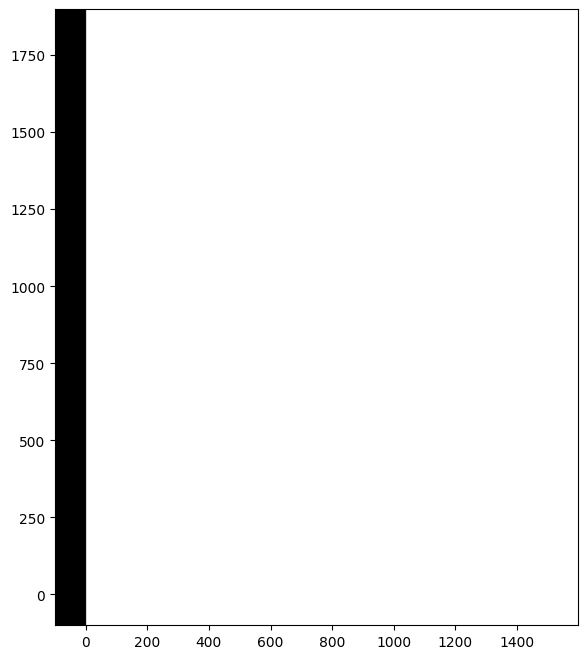

In [5]:
def plot_map(map_data, axs=None, title=None):
    if axs is None:
        plt.figure(figsize=(8, 8))
        axs = plt.gca()
    if title is not None:
        axs.set_title(title)
    axs.imshow(
        map_data.T,
        cmap='gray',
        origin='lower',
        extent=[wx_range[0], wx_range[-1], wy_range[0], wy_range[-1]]
    )
plot_map(wx_map > 0)

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

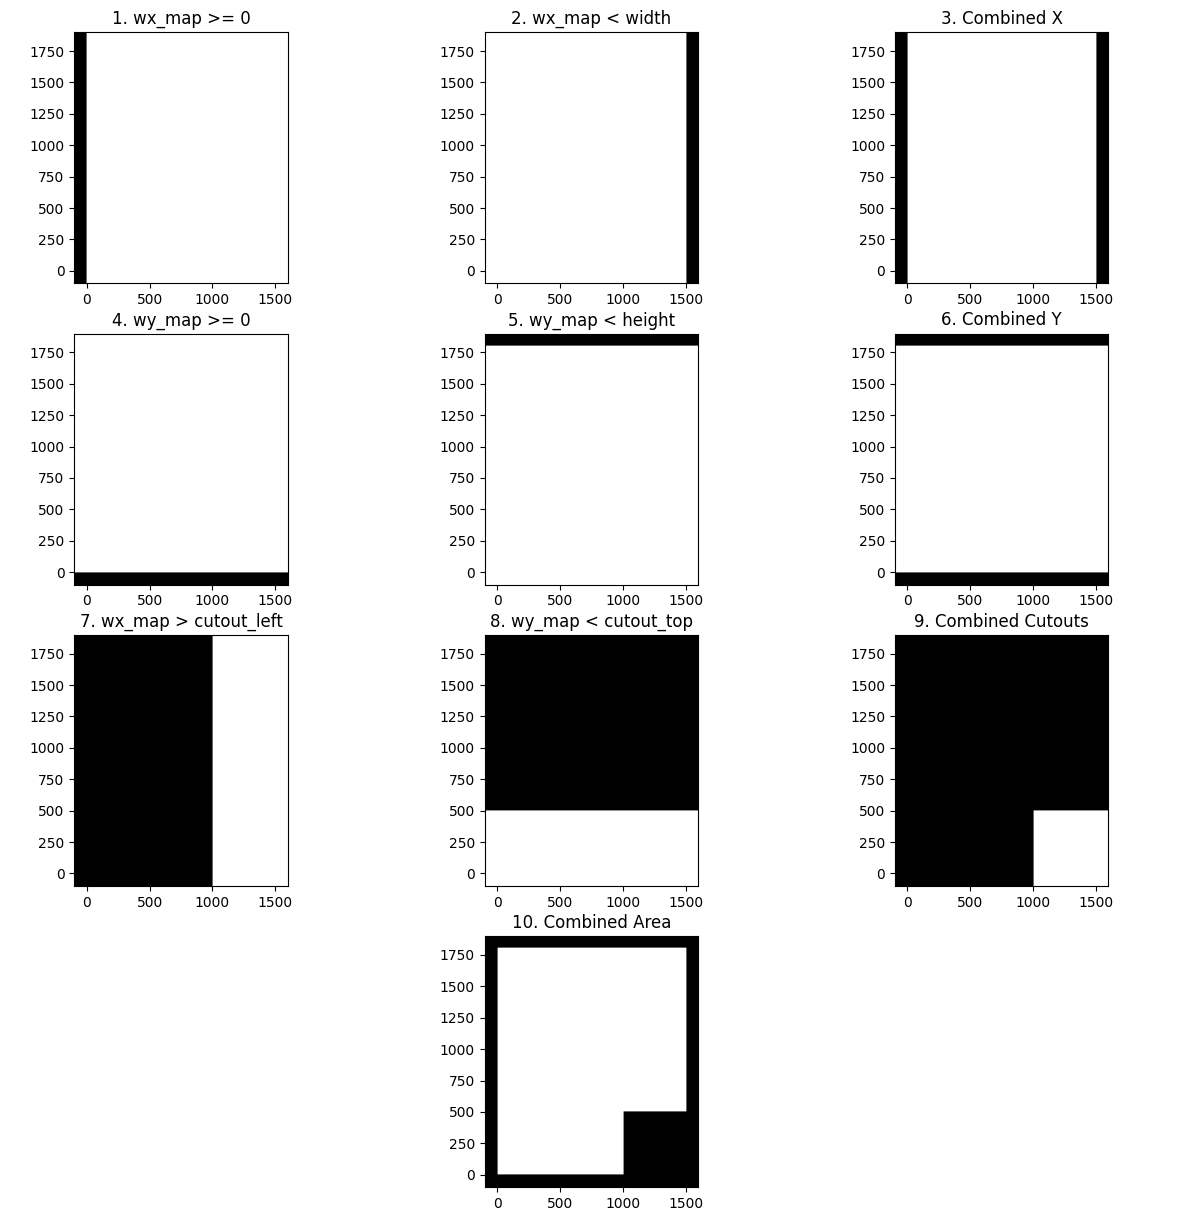

In [6]:
fig, axs = plt.subplots(4, 3, figsize=(15, 15))

# X axis
plot_map(wx_map >= 0, axs=axs[0, 0], title='1. wx_map >= 0')
plot_map(wx_map < width, axs=axs[0, 1], title='2. wx_map < width')
combined_x = (wx_map >= 0) & (wx_map < width)
plot_map(combined_x, axs=axs[0, 2], title='3. Combined X')

# Y axis
plot_map(wy_map >= 0, axs=axs[1, 0], title='4. wy_map >= 0')
plot_map(wy_map < height, axs=axs[1, 1], title='5. wy_map < height')
combined_y = (wy_map >= 0) & (wy_map < height)
plot_map(combined_y, axs=axs[1, 2], title='6. Combined Y')

# Cutouts
plot_map(wx_map > cutout_left, axs=axs[2, 0], title='7. wx_map > cutout_left')
plot_map(wy_map < cutout_top, axs=axs[2, 1], title='8. wy_map < cutout_top')
combined_cutouts = (wx_map > cutout_left) & (wy_map < cutout_top)
plot_map(combined_cutouts, axs=axs[2, 2], title='9. Combined Cutouts')

# Combinations
combined_area = combined_x & combined_y & ~combined_cutouts
plot_map(combined_area, axs=axs[3, 1], title='10. Combined Area')
# Hide unused subplots
axs[3, 0].axis('off')
axs[3, 2].axis('off')


In [7]:
inside_boundary_field = np.full_like(wx_map, low_probability, dtype=np.float32)
inside_boundary_field[combined_area] = 1.0

In [8]:
print("World (1200, 200) = ", inside_boundary_field[margin + 1200, margin + 200])
print("World (-1, 0) = ", inside_boundary_field[margin - 1, margin])
print("World (0, 0) = ", inside_boundary_field[margin, margin])
print("World (1, 0) = ", inside_boundary_field[margin + 1, margin])

World (1200, 200) =  1e-10
World (-1, 0) =  1e-10
World (0, 0) =  1.0
World (1, 0) =  1.0


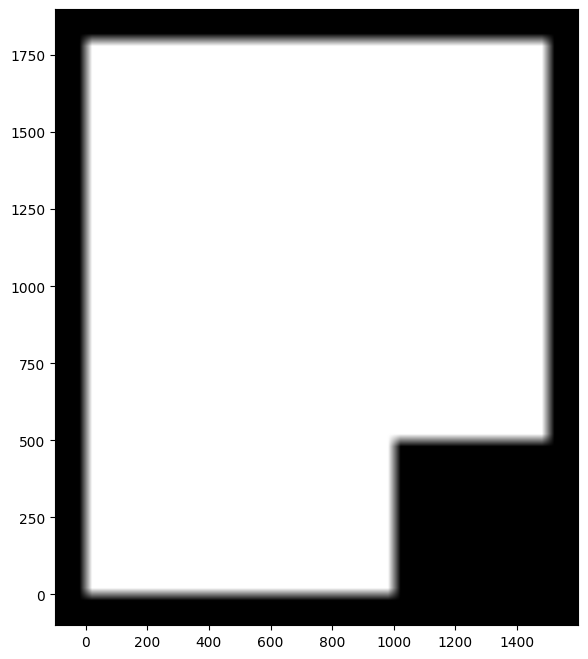

In [9]:
span = 41
blurred = cv2.blur(inside_boundary_field, (span, span))
plot_map(blurred)

In [10]:
print("World (-1, 0) = ", blurred[margin - 1, margin])
print("World (0, 0) = ", blurred[margin, margin])
print("World (21, 21) = ", blurred[margin + 21, margin + 21])
print("World (1, 0) = ", blurred[margin + 1, margin])
print("World (42, 42) = ", blurred[margin + 42, margin + 42])
print("World (-42, -42) = ", blurred[margin - 42, margin - 42])


World (-1, 0) =  0.24985129
World (0, 0) =  0.26234385
World (21, 21) =  1.0
World (1, 0) =  0.27483642
World (42, 42) =  1.0
World (-42, -42) =  1e-10


In [11]:
np.save('../robot/boundary_probabilities.npy', blurred)

In [12]:
corners = np.array([
    (0, height),
    (width, height),
    (width, cutout_top),
    (cutout_left, cutout_top),
    (cutout_left, 0),
    (0, 0)
])

edges = np.array([
    [0, 1],
    [1, 2],
    [2, 3],
    [3, 4],
    [4, 5],
    [5, 0]
])

In [13]:
test_point = np.array([1100, 400])
test_point[::-1]

array([ 400, 1100])

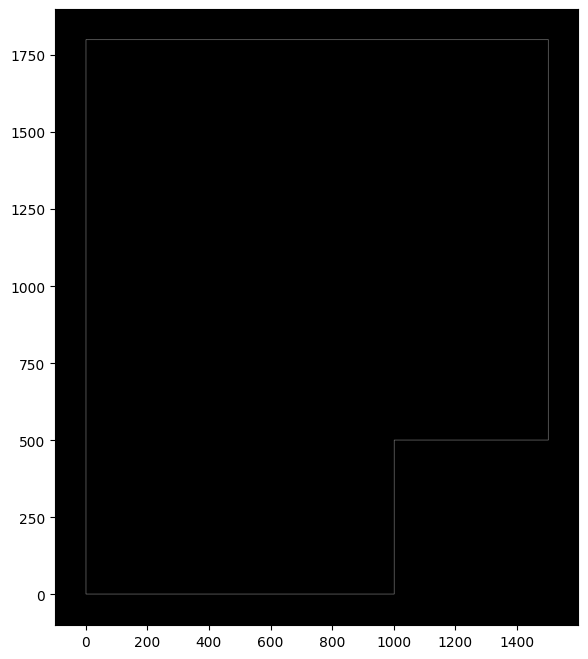

In [14]:
# Create the probability map with edges drawn as 1.0

# Todo - this is the wrong way around...

distance_field = np.full_like(wx_map, low_probability, dtype=np.float32)
for edge in edges:
    p1 = corners[edge[0]] + (margin, margin)
    p2 = corners[edge[1]] + (margin, margin)
    cv2.line(distance_field, p1[::-1], p2[::-1], color=1.0, thickness=1)
# distance_field = distance_field
plot_map(distance_field)

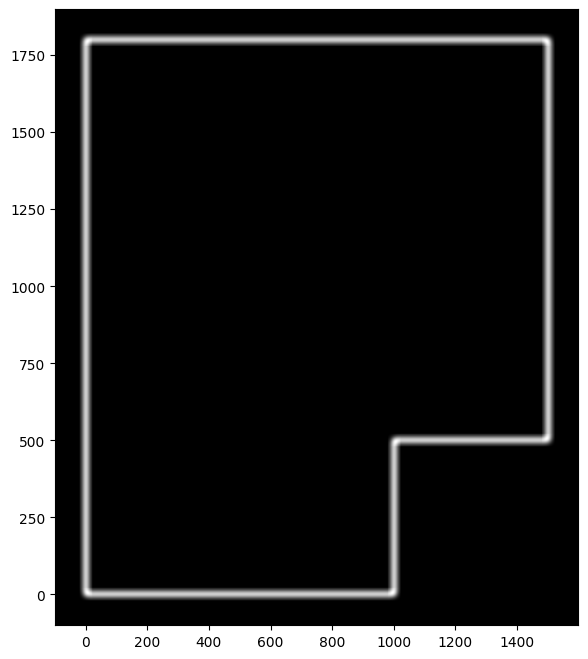

In [15]:
# Blur this map
distance_span = 41
blurred_distance = cv2.GaussianBlur(distance_field, (distance_span, distance_span), 10)
plot_map(blurred_distance)

In [16]:
population_size = 20000
rng = np.random.default_rng()
poses = np.column_stack((
            rng.uniform(0, width, population_size),
            rng.uniform(0, height, population_size),
            rng.uniform(0, 2 * np.pi, population_size)
        ))

In [38]:
poses[0]
polar_middle_to_sensor = (50, 0) # distance (r), angle (theta)
fov_w = np.pi / 4

In [39]:
w_segments = np.linspace(-fov_w/2, fov_w/2, 8)
latest_readings = np.zeros_like(w_segments, dtype=object)
w_segments

array([-0.39269908, -0.28049934, -0.16829961, -0.05609987,  0.05609987,
        0.16829961,  0.28049934,  0.39269908])

In [40]:
# Make some fake inputs - row of 8 distance readings
input_readings = [150, 151, 152, 153, 154, 155, 156, 157]
input_readings

[150, 151, 152, 153, 154, 155, 156, 157]

In [41]:
# Create the set of polar vectors from the robot center to each reading
sensor_polar_vectors = np.array(list(zip(input_readings, w_segments))) + polar_middle_to_sensor
sensor_polar_vectors

array([[ 2.00000000e+02, -3.92699082e-01],
       [ 2.01000000e+02, -2.80499344e-01],
       [ 2.02000000e+02, -1.68299606e-01],
       [ 2.03000000e+02, -5.60998688e-02],
       [ 2.04000000e+02,  5.60998688e-02],
       [ 2.05000000e+02,  1.68299606e-01],
       [ 2.06000000e+02,  2.80499344e-01],
       [ 2.07000000e+02,  3.92699082e-01]])

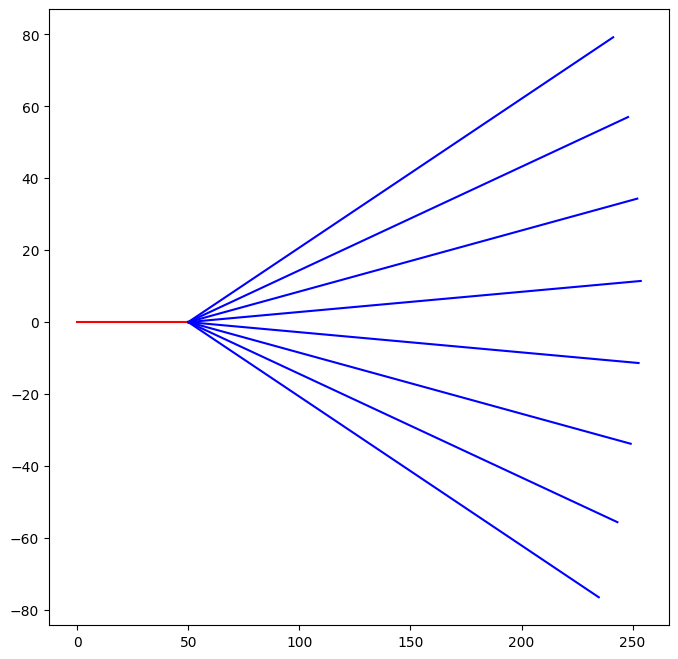

In [ ]:
# convert the polar vectors to cartesian
cartesian_vectors = np.zeros_like(sensor_polar_vectors)
cartesian_vectors[:, 0] = sensor_polar_vectors[:, 1] * np.cos(sensor_polar_vectors[:, 0])
cartesian_vectors[:, 1] = sensor_polar_vectors[:, 1] * np.sin(sensor_polar_vectors[:, 0])

# make the cartesian vector from the robot center to the sensor
middle_to_sensor_cartesian = polar_middle_to_sensor[1] * np.array([
    np.cos(polar_middle_to_sensor[0]),
    np.sin(polar_middle_to_sensor[0])
])

# Plot a line from 0,0 to the sensor position
plt.figure(figsize=(8, 8))
plt.plot([0, middle_to_sensor_cartesian[0]], [0, middle_to_sensor_cartesian[1]], color='red')

# PLot a line from the sensor position to each reading
for vec in cartesian_vectors:
    plt.plot(
        [middle_to_sensor_cartesian[0], middle_to_sensor_cartesian[0] + vec[0]],
        [middle_to_sensor_cartesian[1], middle_to_sensor_cartesian[1] + vec[1]],
        color='blue'
    )


# plt.quiver(0, 0, cartesian_vectors[:, 0], cartesian_vectors[:, 1])
# plt.xlim(-500, 500)
# plt.ylim(-500, 500)
# plt.grid()
# plt.gca().set_aspect('equal', adjustable='box')
# plt.show()


<Figure size 800x800 with 0 Axes>

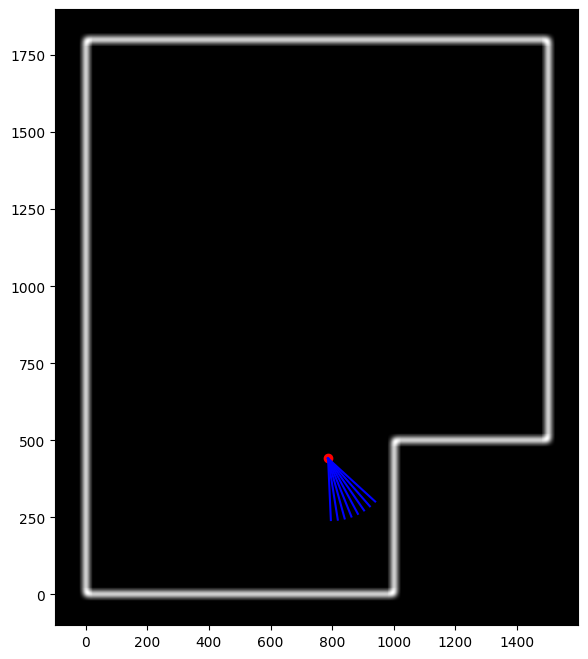

In [65]:
# Map onto one pose (cartesian)
use_pose = poses[20]
# Each of these will still be (r, theta), but now theta is rotated by the robot heading
used_pose_polar_vectors = sensor_polar_vectors + [0, use_pose[2]]
use_pose, used_pose_polar_vectors

# We now need to turn them into relative cartesian coordinates relative to the robot position
# Convert the used_pose_polar_vectors to cartesian (shape 8,2)
use_pose_sense_vectors = np.zeros((used_pose_polar_vectors.shape[0], 2))
use_pose_sense_vectors[:, 0] = used_pose_polar_vectors[:, 0] * np.cos(used_pose_polar_vectors[:, 1])
use_pose_sense_vectors[:, 1] = used_pose_polar_vectors[:, 0] * np.sin(used_pose_polar_vectors[:, 1])
use_pose_sense_vectors += use_pose[:2]

# Plot the robot at the used pose
plt.figure(figsize=(8, 8))
plot_map(blurred_distance)
plt.plot(use_pose[0], use_pose[1], 'ro')  # Robot position
# # Draw a little line to show the heading
# plt.plot(
#     [use_pose[0], use_pose[0] + 100 * np.cos(use_pose[2])],
#     [use_pose[1], use_pose[1] + 100 * np.sin(use_pose[2])],
#     color='red'
# )
# Now plot a line from the robot position to each sensor position
for vec in use_pose_sense_vectors:
    plt.plot(
        [use_pose[0], vec[0]],
        [use_pose[1], vec[1]],
        color='blue'
    )
# use_pose


In [72]:
pose_sensor_vectors = np.zeros((population_size, 8, 2))

for idx, pose in enumerate(poses):
    rotation = pose[2]
    # Position the sensor vectors by rotating them by the robot heading
    rotated_polar_vectors = sensor_polar_vectors + [0, rotation]
    # Convert to cartesian
    cartesian_vectors = np.zeros_like(rotated_polar_vectors)
    cartesian_vectors[:, 0] = rotated_polar_vectors[:, 0] * np.cos(rotated_polar_vectors[:, 1])
    cartesian_vectors[:, 1] = rotated_polar_vectors[:, 0] * np.sin(rotated_polar_vectors[:, 1])
    # Add the robot position to get world coordinates
    cartesian_vectors += pose[:2]

    pose_sensor_vectors[idx:] = cartesian_vectors


This works, next steps are to optimise it. It might be good to split the plot and generate into separate cells, so the transform can be timed.

<Figure size 1000x1000 with 0 Axes>

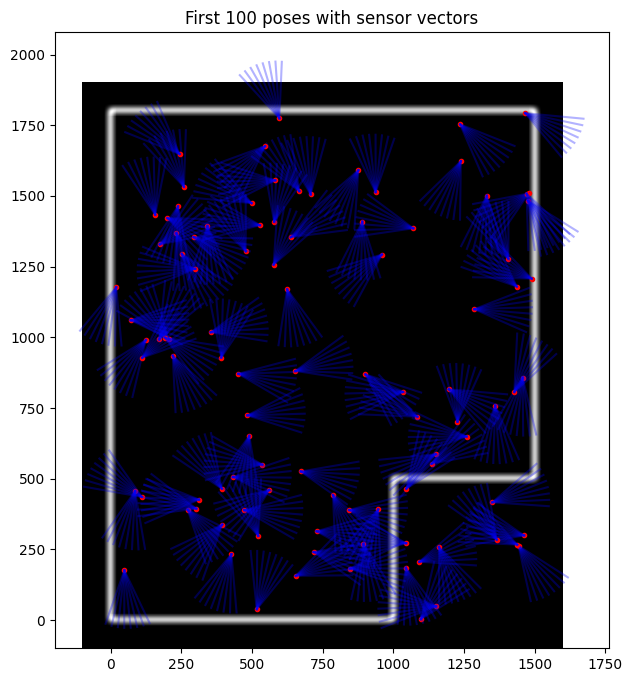

In [74]:
# Plot the robot and its sensor vectors for the first 20 poses
plt.figure(figsize=(10, 10))
plot_map(blurred_distance)

def plot_pose(pose, cartesian_vectors):
    # Plot robot position
    plt.plot(pose[0], pose[1], 'ro', markersize=3)
    for vec in cartesian_vectors:
        plt.plot(
            [pose[0], vec[0]],
            [pose[1], vec[1]],
            color='blue', alpha=0.3
        )

for pose, sensor_vectors in zip(poses[:100], pose_sensor_vectors[:100]):
    plot_pose(pose, sensor_vectors)

plt.title('First 100 poses with sensor vectors')
plt.show()

In [93]:
# Lets do the weight lookups
distance_weights = np.zeros((population_size, 1), dtype=np.float32)
for idx in range(population_size):
    sensor_vectors = pose_sensor_vectors[idx]
    for s_idx, vec in enumerate(sensor_vectors):
        wx = int(np.round(vec[0])) + margin
        wy = int(np.round(vec[1])) + margin
        sense_weights = np.zeros((8,), dtype=np.float32)
        if 0 <= wx < blurred.shape[0] and 0 <= wy < blurred.shape[1]:
            sense_weights[s_idx] = blurred_distance[wx, wy]
        else:
            sense_weights[s_idx] = low_probability
    # sum all the weights together
    distance_weights[idx] = np.sum(sense_weights)
# normalise the weights so each are between 0 and 1
distance_weights += low_probability  # avoid divide by zero
distance_weights /= np.max(distance_weights)

<Figure size 1000x1000 with 0 Axes>

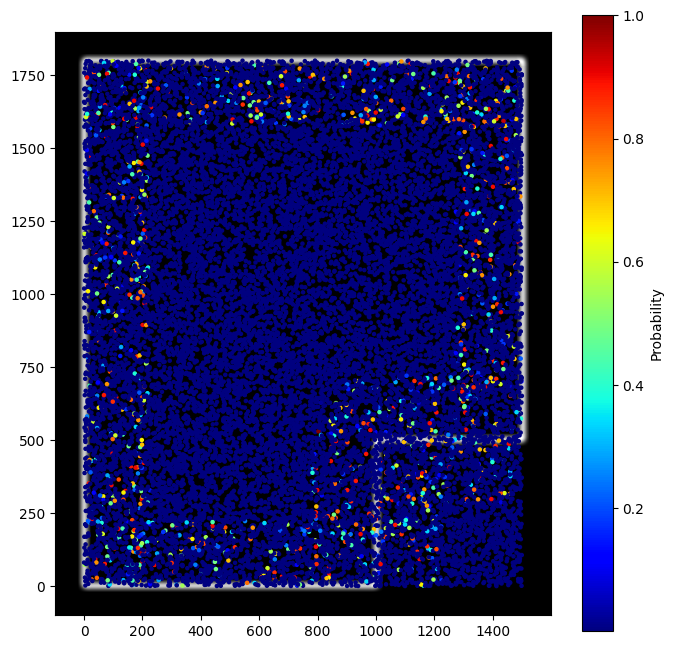

In [94]:
# Plot the probabilities alongside the poses
plt.figure(figsize=(10, 10))
plot_map(blurred_distance)

sc = plt.scatter(poses[:, 0], poses[:, 1], c=distance_weights
, cmap='jet', s=5)
plt.colorbar(sc, label='Probability')

In [1]:
def get_sensor_endpoints(poses, sensor_polar_vector):
    """Given an array of poses (x, y, theta) and a sensor polar vector (r, theta),
    return the world coordinates of the sensor endpoints."""
    sensor_angles = poses[:, 2] + sensor_polar_vector[1]
    sensor_endpoints = np.zeros((poses.shape[0], 2), dtype=np.float)
    sensor_endpoints[:,0] = poses[:, 0] + sensor_polar_vector[0] * np.cos(sensor_angles)
    sensor_endpoints[:,1] = poses[:, 1] + sensor_polar_vector[0] * np.sin(sensor_angles)
    return sensor_endpoints

In [2]:
def observer_distance_sensors(poses, sensor_polar_vectors, distance_field):
    weights = np.zeros((poses.shape[0]), dtype=np.float32)
    for sensor_polar_vector in sensor_polar_vectors:
        sensor_endpoints = get_sensor_endpoints(poses, sensor_polar_vector)
        weights += blurred_distance[sensor_endpoints.astype(int)]
    # Weight should be an array of shape (num_poses,) with the summed weights
    return weights